In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_csv = pd.read_csv('E:/images/Train.csv')
test_csv = pd.read_csv('E:/images/Test.csv')

In [3]:
# Chemin du dossier principal  
dossier_principal = 'E:/cell_images/cell_images'  # Remplacez par le chemin de votre dossier  

# Initialiser une liste pour stocker les données  
donnees = []  

# Itérer sur les sous-dossiers  
for classe in os.listdir(dossier_principal):  
    chemin_classe = os.path.join(dossier_principal, classe)  
    if os.path.isdir(chemin_classe):  # Vérifiez si c'est un dossier  
        for image in os.listdir(chemin_classe):  
            chemin_image = os.path.join(chemin_classe, image)  
            donnees.append((chemin_image, classe))  

# Créer un DataFrame  
df = pd.DataFrame(donnees, columns=['images', 'classes'])  

print(df)

                                                  images      classes
0      E:/cell_images/cell_images\Parasitized\C100P61...  Parasitized
1      E:/cell_images/cell_images\Parasitized\C100P61...  Parasitized
2      E:/cell_images/cell_images\Parasitized\C100P61...  Parasitized
3      E:/cell_images/cell_images\Parasitized\C100P61...  Parasitized
4      E:/cell_images/cell_images\Parasitized\C100P61...  Parasitized
...                                                  ...          ...
27555  E:/cell_images/cell_images\Uninfected\C99P60Th...   Uninfected
27556  E:/cell_images/cell_images\Uninfected\C99P60Th...   Uninfected
27557  E:/cell_images/cell_images\Uninfected\C99P60Th...   Uninfected
27558  E:/cell_images/cell_images\Uninfected\C99P60Th...   Uninfected
27559    E:/cell_images/cell_images\Uninfected\Thumbs.db   Uninfected

[27560 rows x 2 columns]


In [4]:
df.head()

,images,classes
0,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
1,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
2,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
3,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
4,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized


In [6]:
"""df = df.replace('Parasitized', 1)
df = df.replace('Uninfected', 0)"""

"df = df.replace('Parasitized', 1)\ndf = df.replace('Uninfected', 0)"

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27560 entries, 0 to 27559
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   images   27560 non-null  object
 1   classes  27560 non-null  object
dtypes: object(2)
memory usage: 430.8+ KB


In [6]:
df.head()

,images,classes
0,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
1,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
2,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
3,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized
4,E:/cell_images/cell_images\Parasitized\C100P61...,Parasitized


<Axes: xlabel='count', ylabel='classes'>

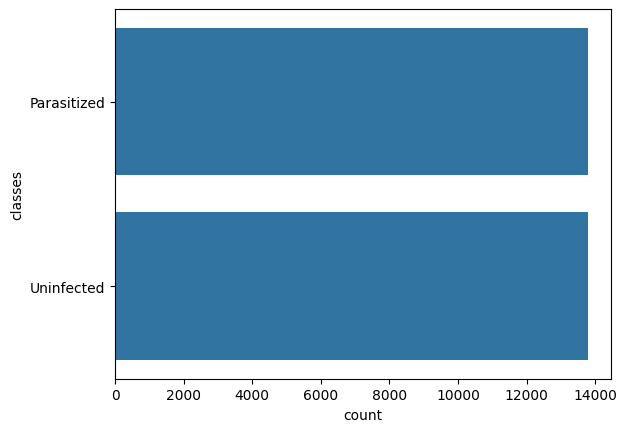

In [7]:
import seaborn as sns

#df['classes'] = df['classes'].apply(str)

sns.countplot(df['classes'])

In [8]:
# input split
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [9]:

train_generator = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2 # 20% pour les donnees de validation
)

val_generator = ImageDataGenerator(rescale = 1./255)

In [10]:
# Creons les ensembles d'entrainement et de validation
train_set = train_generator.flow_from_dataframe(
    train,
    x_col='images',
    y_col='classes',
    target_size=(32, 32),
    batch_size=32,
    class_mode='categorical',
    #subset='training'
)
val_set = val_generator.flow_from_dataframe(
    test,
    x_col='images',
    y_col='classes',
    target_size=(32, 32),
    batch_size=32,
    class_mode='categorical',
    #subset='validation'
)

Found 22046 validated image filenames belonging to 2 classes.


c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\legacy\preprocessing\image.py:920: UserWarning: Found 2 invalid image filename(s) in x_col="images". These filename(s) will be ignored.
  warnings.warn(


Found 5512 validated image filenames belonging to 2 classes.


In [ ]:
# Mise en place du modele

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Variables
INPUT_SHAPE = (32, 32, 3)
FILTER1_SIZE = 32
FILTER2_SIZE = 64
FILTER3_SIZE = 128
FILTER_SHAPE = (3, 3)
POOL_SHAPE = (2, 2)
FULLY_CONNECTED_LAYER_SIZE = 300
NUM_CLASSES = 2

# Definir le modele, architecture implementation
model = Sequential()
model.add(Conv2D(FILTER1_SIZE, FILTER_SHAPE, activation='relu', input_shape = INPUT_SHAPE))
model.add(MaxPooling2D(POOL_SHAPE))
model.add(Conv2D(FILTER2_SIZE, FILTER_SHAPE, activation='relu', input_shape = INPUT_SHAPE))
model.add(MaxPooling2D(POOL_SHAPE))
model.add(Conv2D(FILTER3_SIZE, (2, 2), activation='relu', input_shape = INPUT_SHAPE))
model.add(MaxPooling2D(POOL_SHAPE))
model.add(Flatten())
model.add(Dense(FULLY_CONNECTED_LAYER_SIZE, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(FULLY_CONNECTED_LAYER_SIZE, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(FULLY_CONNECTED_LAYER_SIZE, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(NUM_CLASSES, activation='softmax'))

# resume du modele
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │        38,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,190 (1.04 MB)

 Trainable params: 272,190 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Formation du modele
#from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

BATCH_SIZE = 32
EPOCHS = 10
METRICS = [
    'accuracy',
    Precision(name='precision'),
    Recall(name='recall')
]

# Early stopping
#early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True) #callbacks=[early_stopping]


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics = METRICS)

# Entrainement du modele
training_history = model.fit(train_set, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=val_set)

Epoch 1/10


c:\Users\pc\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


689/689 ━━━━━━━━━━━━━━━━━━━━ 718s 1s/step - accuracy: 0.6741 - loss: 0.5683 - precision: 0.6741 - recall: 0.6741 - val_accuracy: 0.8567 - val_loss: 0.3479 - val_precision: 0.8567 - val_recall: 0.8567
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 58s 84ms/step - accuracy: 0.8655 - loss: 0.3415 - precision: 0.8655 - recall: 0.8655 - val_accuracy: 0.8911 - val_loss: 0.2806 - val_precision: 0.8911 - val_recall: 0.8911
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.8765 - loss: 0.3172 - precision: 0.8765 - recall: 0.8765 - val_accuracy: 0.9002 - val_loss: 0.2683 - val_precision: 0.9002 - val_recall: 0.9002
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - accuracy: 0.8854 - loss: 0.3027 - precision: 0.8854 - recall: 0.8854 - val_accuracy: 0.8926 - val_loss: 0.2655 - val_precision: 0.8926 - val_recall: 0.8926
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.8913 - loss: 0.2896 - precision: 0.8913 - recall: 0.8913 - val_accuracy: 0.8989 - val_loss: 0.26

# Visualisation des Resultats

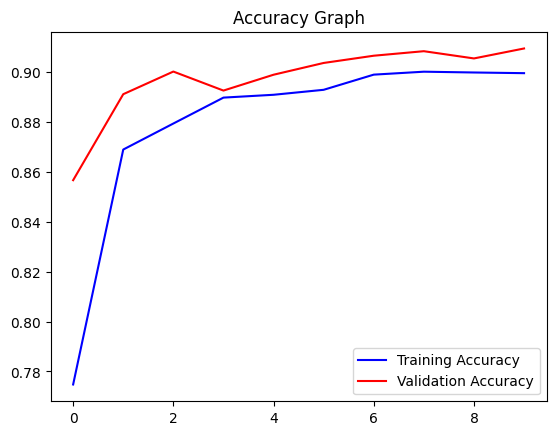

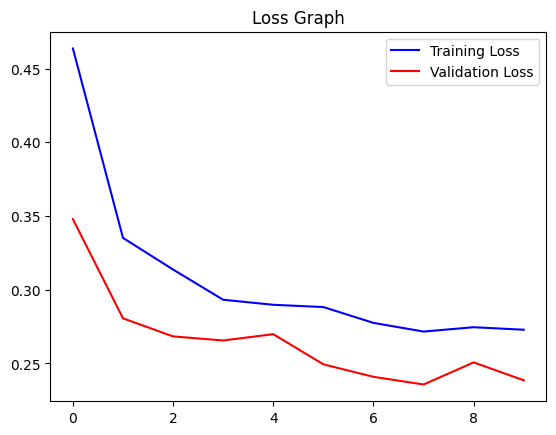

In [17]:
import matplotlib.pyplot as plt

acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = training_history.history['loss']
val_loss = training_history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()

In [ ]:
# Save the trained model1
modelFileName = 'models2/shape_classifier.h5'
model.save(modelFileName)
del model  # deletes the existing model variable
print('model saved as', modelFileName)

model saved as models2/shape_classifier.h5


In [ ]:
# Save the trained model2
modelFileName = 'models3/shape_classifier.h5'
model.save(modelFileName)
del model  # deletes the existing model variable
print('model saved as', modelFileName)

model saved as models3/shape_classifier.h5


In [ ]:
from pathlib import Path
# Load train and test files
train = pd.read_csv('E:/images/Train.csv')
test = pd.read_csv('E:/images/Test.csv')

# Add an image_path column
train['image_path'] = [Path('E:/images' + x) for x in train.Image_ID]
test['image_path'] = [Path('E:/images' + x) for x in test.Image_ID]

# Map str classes to ints (label encoding targets)
train['class_id'] = train['class'].map({'Trophozoite': 0, 'WBC': 1, 'NEG': 2})

# Preview the head of the train set
train.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,image_path,class_id
0,id_u3q6jdck4j.jpg,Trophozoite,1.0,712,1241,737,1270,E:\imagesid_u3q6jdck4j.jpg,0
1,id_a6cl90trri.jpg,Trophozoite,1.0,558,1566,600,1604,E:\imagesid_a6cl90trri.jpg,0
2,id_qvc2le9sm8.jpg,Trophozoite,1.0,1317,2788,1448,2914,E:\imagesid_qvc2le9sm8.jpg,0
3,id_w8xnbd5rvm.jpg,Trophozoite,1.0,925,1744,1041,1823,E:\imagesid_w8xnbd5rvm.jpg,0
4,id_6dop09rk02.jpg,NEG,1.0,0,0,0,0,E:\imagesid_6dop09rk02.jpg,2


In [ ]:
train = train[~(train['class'] == 'WBC')].reset_index(drop = True)
train.head()

,Image_ID,class,confidence,ymin,xmin,ymax,xmax,image_path,class_id
0,id_u3q6jdck4j.jpg,Trophozoite,1.0,712,1241,737,1270,E:\imagesid_u3q6jdck4j.jpg,0
1,id_a6cl90trri.jpg,Trophozoite,1.0,558,1566,600,1604,E:\imagesid_a6cl90trri.jpg,0
2,id_qvc2le9sm8.jpg,Trophozoite,1.0,1317,2788,1448,2914,E:\imagesid_qvc2le9sm8.jpg,0
3,id_w8xnbd5rvm.jpg,Trophozoite,1.0,925,1744,1041,1823,E:\imagesid_w8xnbd5rvm.jpg,0
4,id_i8qcpi8ey9.jpg,Trophozoite,1.0,501,1141,532,1170,E:\imagesid_i8qcpi8ey9.jpg,0


In [ ]:
test_x = train.drop(['class', 'class_id', 'ymin', 'xmin', 'ymax', 'xmax', 'confidence'], axis=1)
test_y = train.drop(['class_id', 'ymin', 'xmin', 'ymax', 'xmax', 'confidence', 'image_path'], axis=1)

test_x

0        False
1        False
2        False
3        False
4        False
         ...  
15833    False
15834    False
15835    False
15836    False
15837    False
Name: Image_ID, Length: 15838, dtype: bool

In [19]:
from tensorflow.keras.models import load_model
import numpy as np

"""modele_path = 'C:/Users/pc/Malaria_Detection/models3/shape_classifier.h5'
model = load_model(modele_path)
accuracy, loss = model.evaluate(test_x, test_y)"""

"modele_path = 'C:/Users/pc/Malaria_Detection/models3/shape_classifier.h5'\nmodel = load_model(modele_path)\naccuracy, loss = model.evaluate(test_x, test_y)"

In [17]:
classnames = list(train_set.class_indices.keys())
classnames

['Parasitized', 'Uninfected']

In [25]:
from tensorflow.keras.preprocessing import image

def prediction_maturity_papaya(image_path, model_path):
    
    # Chargeons le modele sauvegarde
    model = load_model(model_path)
    
    # Charger et pretraitons l'image
    img = image.load_img(image_path, target_size=(32, 32))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0 # normaliser l'image
    
    # Predire la classe
    prediction = model.predict(img_array).flatten() # transformation en tableau 1D
    
    # Creation d'un dictionnaire pour les resultats
    results = {
        classnames[i]: float(prediction[i])
        for i in range(len(classnames))
    }
    
    # Tri par probabilites decroissantes
    resultats_tries = sorted(results.items(), key=lambda x: x[1], reverse=True)
    return resultats_tries



resultat = prediction_maturity_papaya('C:/Users/pc/Downloads/NIH-NLM-ThinBloodSmearsPf/Polygon Set/142C38P3thinF_original/Img/IMG_20150621_112138.jpg' ,'C:/Users/pc/Malaria_Detection/models3/shape_classifier.h5')
for class_name, proba in resultat:
    print(f"{class_name}: {proba:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Parasitized: 80.40%
Uninfected: 19.60%
